MOVIE RATING PREDICTION WITH PYTHON

Import Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

Load Dataset

In [2]:
data = pd.read_csv("IMDb Movies India.csv", encoding='latin1')
data.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


Dataset Information

In [3]:
print("\nDataset Shape:")
print(data.shape)

print("\nDataset Information:")
print(data.info())

print("\nMissing Values:")
print(data.isnull().sum())


Dataset Shape:
(15509, 10)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB
None

Missing Values:
Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64


Data Cleaning

In [4]:
data = data.dropna(subset=['Rating'])

data['Genre'] = data['Genre'].fillna("Unknown")
data['Director'] = data['Director'].fillna("Unknown")
data['Actor 1'] = data['Actor 1'].fillna("Unknown")
data['Actor 2'] = data['Actor 2'].fillna("Unknown")
data['Actor 3'] = data['Actor 3'].fillna("Unknown")

data = data[['Genre','Director','Actor 1','Actor 2','Actor 3','Rating']]

Encoding

In [5]:
le = LabelEncoder()

for col in ['Genre','Director','Actor 1','Actor 2','Actor 3']:
    data[col] = le.fit_transform(data[col])

Train-Test Split

In [6]:
X = data.drop('Rating', axis=1)
y = data['Rating']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Model Training

In [7]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Prediction and Evaluation

In [8]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Performance")
print("Mean Absolute Error:", mae)
print("Mean Squared Error :", mse)
print("R2 Score :", r2)


Model Performance
Mean Absolute Error: 1.0232461700336701
Mean Squared Error : 1.6475792115856485
R2 Score : 0.11379742465064835


Visualization

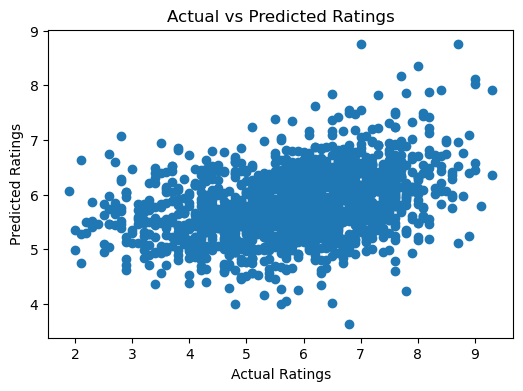

In [9]:
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Actual vs Predicted Ratings")

plt.show()

Sample Prediction

In [10]:
sample_movie = X.iloc[[0]]

prediction = model.predict(sample_movie)

print("\nPredicted Rating:", prediction[0])


Predicted Rating: 6.172000000000001
